In [1]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller

## Data collection 

In [2]:
tickers="AAPL, MSFT, AMZN, NVDA, GOOGL, GOOG, META, TSLA, BRK-B, UNH, JNJ, JPM, V, PG, XOM, HD, MA, CVX, MRK, ABBV, AVGO, COST, KO, PEP, WMT, BAC, CRM, DIS, ORCL, TMO, ACN, NFLX, LIN, ABT, MCD, CSCO, DHR, VZ, WFC, INTU, CMCSA, ADP, TXN, IBM, PM, NKE, RTX, HON, QCOM, UPS, LOW, BMY, AMGN, SPGI, SCHW, CAT, GS, BLK, MDLZ, CVS, AXP, DE, MS, AMT, C, BA, T, ISRG, NOW, GILD, LMT, ADI, MMM, MO, SYK, ZTS, CB, TJX, ETN, CI, SO, VRTX, PGR, MU, PLD, REGN, USB, WM, BK, KLAC, LRCX, FIS, ICE, APD, HCA, SHW, EL, NOC"
tickers_list = tickers.split(", ")

In [3]:
df = yf.download(
    tickers,
    start="2005-01-01",
    end="2019-12-30",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [4]:
df_test = yf.download(
    tickers,
    start="2019-12-30",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [5]:
print('The df_test shape is:', df_test.shape)
print('The df shape is:', df.shape)

The df_test shape is: (1594, 490)
The df shape is: (3773, 490)


## Data Cleaning 

In [6]:
df = df.xs("Close", axis=1, level=1).pct_change()
df=pd.DataFrame(df)
df_test = df_test.xs("Close", axis=1, level=1).pct_change()
df_test=pd.DataFrame(df_test)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3773 entries, 2005-01-03 to 2019-12-27
Data columns (total 98 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CSCO    3772 non-null   float64
 1   META    1914 non-null   float64
 2   NKE     3772 non-null   float64
 3   VRTX    3772 non-null   float64
 4   LMT     3772 non-null   float64
 5   UNH     3772 non-null   float64
 6   DE      3772 non-null   float64
 7   APD     3772 non-null   float64
 8   QCOM    3772 non-null   float64
 9   MA      3421 non-null   float64
 10  USB     3772 non-null   float64
 11  COST    3772 non-null   float64
 12  ICE     3551 non-null   float64
 13  VZ      3772 non-null   float64
 14  ETN     3772 non-null   float64
 15  REGN    3772 non-null   float64
 16  ABT     3772 non-null   float64
 17  NFLX    3772 non-null   float64
 18  ADI     3772 non-null   float64
 19  DIS     3772 non-null   float64
 20  UPS     3772 non-null   float64
 21  CI      3772 non-nu

In [8]:
train_counts = df.notna().sum() 
test_counts = df_test.notna().sum()

max_train = train_counts.max()
max_test = test_counts.max()

keep_cols = train_counts[train_counts == max_train].index.intersection(
    test_counts[test_counts == max_test].index
)

df = df[keep_cols].copy().dropna()
df_test = df_test[keep_cols].copy().dropna()

print(f"Kept {len(keep_cols)} columns with maximum data in both sets.")
print("Train counts for kept columns:", train_counts[keep_cols].unique())
print("Test counts for kept columns :", test_counts[keep_cols].unique())

Kept 87 columns with maximum data in both sets.
Train counts for kept columns: [3772]
Test counts for kept columns : [1593]


In [9]:
df.head()

Ticker,CSCO,NKE,VRTX,LMT,UNH,DE,APD,QCOM,USB,COST,...,C,AXP,EL,TMO,LIN,WMT,GILD,MS,PLD,MO
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-04,-0.039337,-0.014224,-0.014648,-0.016971,-0.010274,-0.023855,-0.019122,-0.004490,-0.004831,-0.017954,...,-0.008494,-0.015024,-0.020180,-0.012466,-0.014325,-0.002437,-0.024475,-0.010734,-0.000494,0.006927
2005-01-05,0.000539,-0.011969,-0.018831,0.025146,0.003499,-0.009691,0.000878,0.004272,0.005178,0.003826,...,0.012537,-0.009281,-0.019028,-0.002730,-0.020299,0.001315,-0.013872,-0.005786,-0.041008,-0.001802
2005-01-06,0.015078,-0.001246,0.062626,-0.002197,0.022086,0.013898,0.006142,0.016308,-0.002254,0.014401,...,0.009699,-0.005144,0.013236,0.000684,0.009889,0.014262,0.006285,0.023645,0.009273,-0.007056
2005-01-07,-0.006897,-0.005894,-0.002852,0.004770,-0.007961,-0.013848,0.005406,0.005117,-0.017425,-0.008560,...,-0.005723,-0.007385,0.008784,-0.014701,-0.000234,-0.001110,-0.002082,-0.003909,-0.002297,0.014709
2005-01-10,0.000000,0.009920,0.027645,0.004199,0.004242,-0.004539,0.000694,-0.001620,-0.002955,0.001895,...,-0.006372,0.002046,0.004911,0.002775,-0.003498,-0.005001,0.000298,-0.000178,-0.007930,0.013029


#### Row Return to Log Return

In [ ]:
import numpy as np
returns = np.log(1+df)
returns_F = np.log(1+df_test)   # returns_F is the returns in the future period (test set)
returns.head()

Ticker,CSCO,NKE,VRTX,LMT,UNH,DE,APD,QCOM,USB,COST,...,C,AXP,EL,TMO,LIN,WMT,GILD,MS,PLD,MO
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-04,-0.040132,-0.014326,-0.014757,-0.017117,-0.010328,-0.024144,-0.019307,-0.004500,-0.004843,-0.018117,...,-0.008530,-0.015138,-0.020386,-0.012544,-0.014428,-0.002440,-0.024779,-0.010792,-0.000494,0.006903
2005-01-05,0.000539,-0.012041,-0.019010,0.024835,0.003493,-0.009738,0.000878,0.004263,0.005165,0.003819,...,0.012459,-0.009324,-0.019211,-0.002733,-0.020508,0.001314,-0.013969,-0.005803,-0.041872,-0.001803
2005-01-06,0.014966,-0.001246,0.060744,-0.002199,0.021845,0.013803,0.006123,0.016176,-0.002256,0.014298,...,0.009652,-0.005157,0.013149,0.000684,0.009840,0.014161,0.006266,0.023370,0.009230,-0.007081
2005-01-07,-0.006921,-0.005912,-0.002856,0.004759,-0.007993,-0.013944,0.005391,0.005104,-0.017578,-0.008596,...,-0.005739,-0.007413,0.008746,-0.014810,-0.000234,-0.001110,-0.002084,-0.003917,-0.002300,0.014602
2005-01-10,0.000000,0.009871,0.027270,0.004191,0.004233,-0.004550,0.000694,-0.001621,-0.002960,0.001893,...,-0.006392,0.002044,0.004899,0.002772,-0.003504,-0.005014,0.000298,-0.000178,-0.007962,0.012945


In [12]:
# align columns of returns_F to match training scaler
returns_F = returns_F[returns.columns]

#### Average Correlation between  the selected assets

In [13]:
returns.corr().mean().mean()

np.float64(0.42187722582596227)

## Checking the stationarity

In [53]:
# Stationarity is very important for principal component analysis (PCA) 
# because PCA assumes that the underlying data is stationary. 
# If the data is non-stationary, it can lead to misleading results 
# and incorrect interpretations of the principal components. 
results = returns.apply(lambda col: adfuller(col)[1])  # Extract p-values for each asset's returns
results = pd.Series(results, index=returns.columns)
results.max()

np.float64(2.0727983785819372e-17)

## PCA application

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

In [17]:
pca = PCA()
pca.fit(returns_scaled)

PCA()

In [18]:
eigenvalues      = pd.Series(pca.explained_variance_)          # variance of each PC
eigenvectors     = pd.DataFrame(pca.components_)                  # shape: (N_components, N_assets)
explained_ratio  = pd.Series(pca.explained_variance_ratio_)    # % variance per PC
cumulative_var   = np.cumsum(explained_ratio)

In [19]:
eigenvalues.head()

0    37.300242
1     3.187824
2     2.676644
3     1.682631
4     1.518297
dtype: float64

In [20]:
eigenvectors.head()

,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.114996,0.106675,0.068932,0.101291,0.092028,0.112466,0.124453,0.099387,0.114144,0.102516,...,0.107249,0.124598,0.096132,0.113169,0.123155,0.089430,0.085652,0.121406,0.115780,0.084469
1,0.003998,-0.009162,-0.033436,-0.091165,-0.064648,0.073954,-0.013820,0.005915,0.243067,-0.077151,...,0.249515,0.155317,-0.031989,-0.065474,-0.014555,-0.135736,-0.102937,0.160117,0.119173,-0.183970
2,0.100925,0.012730,0.078567,-0.022540,-0.070356,0.078723,0.032586,0.148267,-0.166482,-0.036150,...,-0.137892,-0.086013,0.005604,0.047675,0.026247,-0.096925,0.054817,-0.113947,-0.085624,-0.082079
3,-0.036999,-0.027530,0.289969,-0.099951,0.199848,-0.194043,-0.133375,0.005944,0.024279,-0.000352,...,0.095865,0.019291,-0.060382,0.078874,-0.135169,-0.000511,0.286675,0.059527,-0.033120,-0.021800
4,0.042307,0.139191,-0.091837,-0.144202,-0.144360,-0.140733,-0.131258,0.017381,0.060132,0.269650,...,-0.045452,0.009060,0.065942,-0.120073,-0.126246,0.249932,-0.108861,-0.076738,0.104480,0.039511


In [21]:
explained_ratio

0     0.428625
1     0.036632
2     0.030758
3     0.019335
4     0.017447
        ...   
82    0.001734
83    0.001662
84    0.001587
85    0.001457
86    0.000024
Length: 87, dtype: float64

In [22]:
cumulative_var.tail()

82    0.995269
83    0.996931
84    0.998519
85    0.999976
86    1.000000
dtype: float64

## The Marchenko-Pastur filter 

In [23]:
T, N = returns_scaled.shape
lambda_noise = (1 + np.sqrt(N / T))**2
signal_eigenvalues  = eigenvalues[eigenvalues.values > lambda_noise].reset_index(drop=True)
signal_eigenvectors = eigenvectors[eigenvalues.values > lambda_noise]  # shape: (n_signal, N_assets)
n_signal = np.sum(eigenvalues.values > lambda_noise)
print(f"T={T}, N={N}")
print(f"Noise threshold (lambda_max): {lambda_noise:.4f}")
print(f"Signal PCs: {n_signal}")

T=3772, N=87
Noise threshold (lambda_max): 1.3268
Signal PCs: 7


## Equal weighted Portfolio 

#### Construction

In [24]:
N = returns.shape[1]
weights = np.ones(N) / N

In [ ]:
# calculate portfolio returns in the test set using the same weights as in the training set
portfolio_returns = returns_F @ weights 
portfolio_returns.columns = ['Returns']
portfolio_returns.describe()

count    1593.000000
mean        0.000460
std         0.012361
min        -0.128910
25%        -0.004372
50%         0.000704
75%         0.006071
max         0.097587
dtype: float64

<Axes: title={'center': 'Equal-Weighted Portfolio Returns'}, xlabel='Date'>

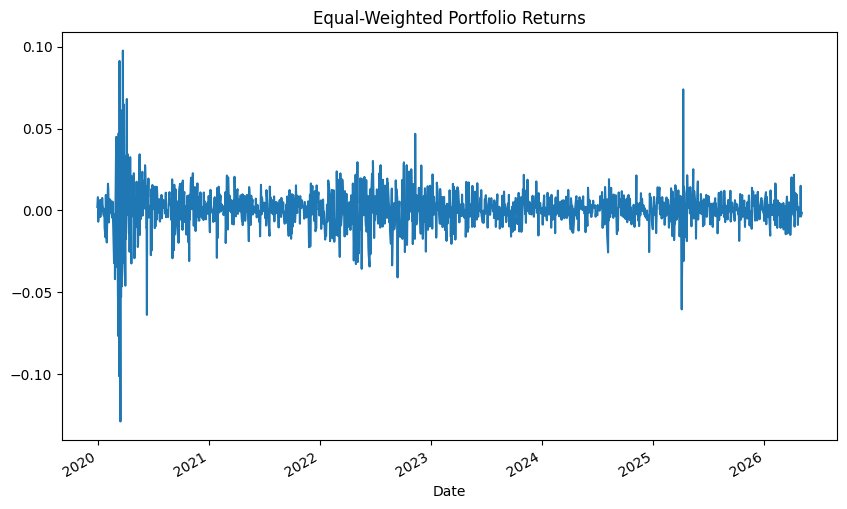

In [26]:
portfolio_returns.plot(title='Equal-Weighted Portfolio Returns', figsize=(10,6))

<Axes: title={'center': 'Cumulative Returns of Equal-Weighted Portfolio'}, xlabel='Date'>

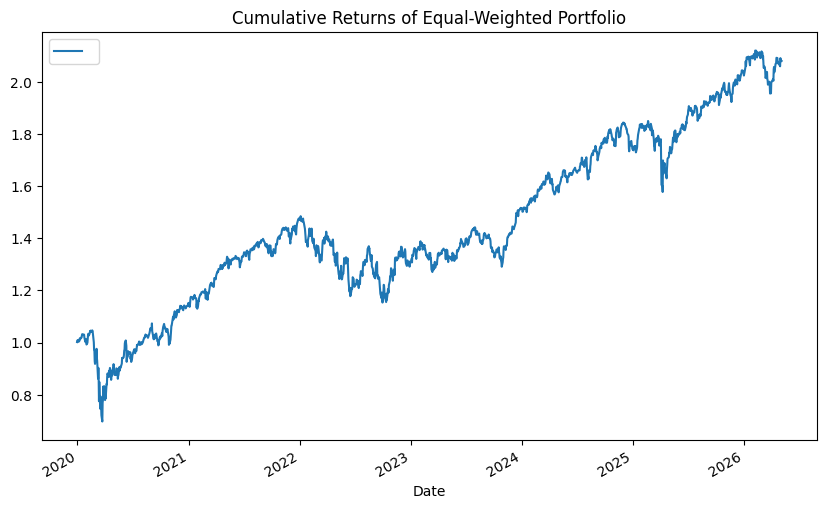

In [27]:
cum_returns = np.exp(portfolio_returns.cumsum()) # cumulative product of (1 + returns) to get wealth index
cum_returns.plot(title='Cumulative Returns of Equal-Weighted Portfolio', figsize=(10,6),legend=True)

#### Maximum Drawdown / Sharp ratio

In [28]:
wealth_index=cum_returns
previous_peak = wealth_index.cummax()

<Axes: title={'center': 'Wealth Index and Drawdown'}, xlabel='Date'>

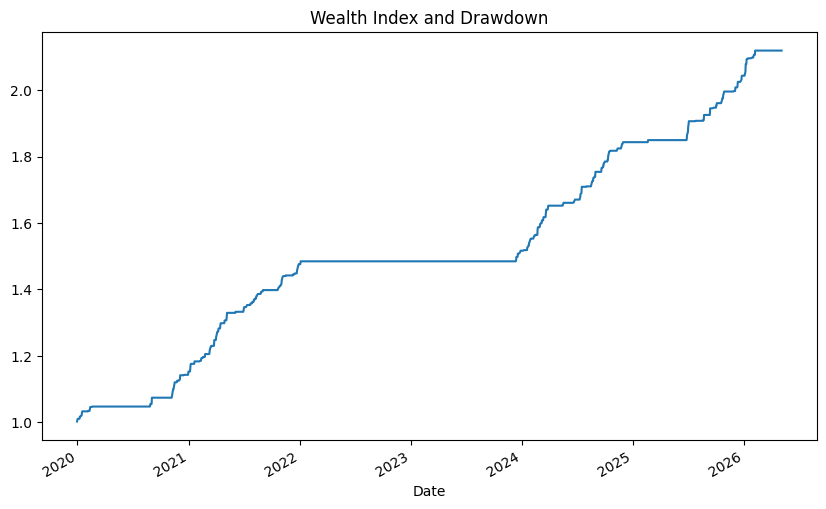

In [29]:
previous_peak.plot(title='Wealth Index and Drawdown', figsize=(10,6), label='Wealth Index')

In [30]:
ew_drawdown = (wealth_index - previous_peak) / previous_peak
print('Max drawdown of', ew_drawdown.min().round(2))

Max drawdown of -0.33


<Axes: title={'center': 'Drawdown'}, xlabel='Date'>

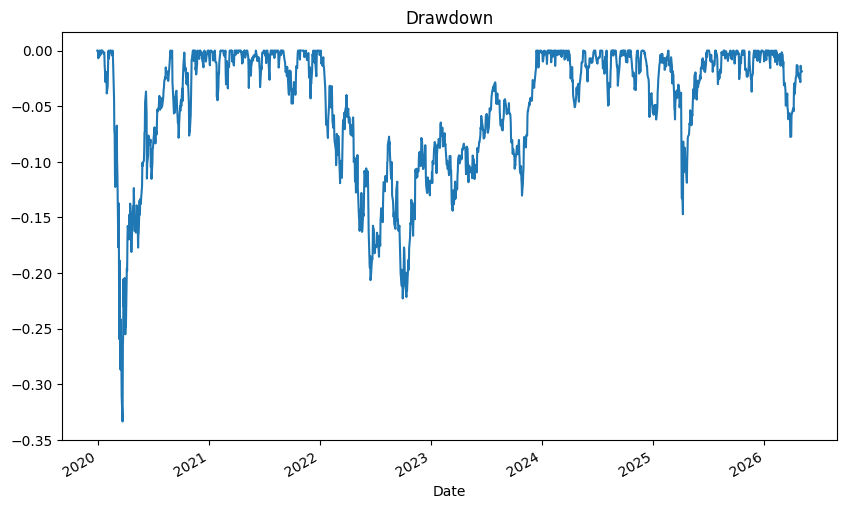

In [31]:
ew_drawdown.plot(title="Drawdown", figsize=(10,6))

In [32]:
ew_ann_return = portfolio_returns.mean() * 252
ew_ann_vol = portfolio_returns.std() * np.sqrt(252)
risk_free=0 ## Assuming risk-free rate is 0 for simplicity; adjust as needed
ew_sharpe = (ew_ann_return - risk_free) / ew_ann_vol   

print("Equal-weighted portfolio")
print(f"Annualized return      : {ew_ann_return:.4f}")
print(f"Annualized volatility  : {ew_ann_vol:.4f}")
print(f"Sharpe ratio           : {ew_sharpe:.4f}")

Equal-weighted portfolio
Annualized return      : 0.1158
Annualized volatility  : 0.1962
Sharpe ratio           : 0.5902


#### E-Q Portfolio risk exposure 

In [33]:
pc_exposure = signal_eigenvectors @ weights
variance_contrib = (pc_exposure**2) * signal_eigenvalues
variance_contrib = variance_contrib / variance_contrib.sum()
variance_contrib*100

0    99.944843
1     0.026286
2     0.003074
3     0.023283
4     0.001738
5     0.000751
6     0.000024
dtype: float64

In [34]:
p   = variance_contrib
ENB = np.exp(-np.sum(p * np.log(p + 1e-10))) # add small constant to avoid log(0)

In [35]:
print(f"Assets in portfolio      : {N}")
print(f"Signal PCs (real factors): {n_signal}")
print(f"Effective Number of Bets : {ENB:.2f}")
print(f"Diversification Ratio    : {ENB / N * 100:.2f}%")
print(f"")
print(f"Interpretation: your {N}-asset portfolio")
print(f"behaves like {ENB:.1f} independent bets")
print(f"out of a possible {N}")

Assets in portfolio      : 87
Signal PCs (real factors): 7
Effective Number of Bets : 1.01
Diversification Ratio    : 1.16%

Interpretation: your 87-asset portfolio
behaves like 1.0 independent bets
out of a possible 87


## interpretation of the 7 real factors

In [36]:
tickers = list(returns.columns)

loadings = pd.DataFrame(
    signal_eigenvectors.values,
    index   = [f'PC{i}' for i in range(n_signal)],
    columns = tickers
)
loadings

,CSCO,NKE,VRTX,LMT,UNH,DE,APD,QCOM,USB,COST,...,C,AXP,EL,TMO,LIN,WMT,GILD,MS,PLD,MO
PC0,0.114996,0.106675,0.068932,0.101291,0.092028,0.112466,0.124453,0.099387,0.114144,0.102516,...,0.107249,0.124598,0.096132,0.113169,0.123155,0.089430,0.085652,0.121406,0.115780,0.084469
PC1,0.003998,-0.009162,-0.033436,-0.091165,-0.064648,0.073954,-0.013820,0.005915,0.243067,-0.077151,...,0.249515,0.155317,-0.031989,-0.065474,-0.014555,-0.135736,-0.102937,0.160117,0.119173,-0.183970
PC2,0.100925,0.012730,0.078567,-0.022540,-0.070356,0.078723,0.032586,0.148267,-0.166482,-0.036150,...,-0.137892,-0.086013,0.005604,0.047675,0.026247,-0.096925,0.054817,-0.113947,-0.085624,-0.082079
PC3,-0.036999,-0.027530,0.289969,-0.099951,0.199848,-0.194043,-0.133375,0.005944,0.024279,-0.000352,...,0.095865,0.019291,-0.060382,0.078874,-0.135169,-0.000511,0.286675,0.059527,-0.033120,-0.021800
PC4,0.042307,0.139191,-0.091837,-0.144202,-0.144360,-0.140733,-0.131258,0.017381,0.060132,0.269650,...,-0.045452,0.009060,0.065942,-0.120073,-0.126246,0.249932,-0.108861,-0.076738,0.104480,0.039511
PC5,0.061814,-0.063100,-0.142162,-0.081558,0.004882,0.053174,0.037137,0.041647,-0.003480,-0.072223,...,0.008523,-0.003052,-0.062917,-0.047614,0.087973,-0.084058,-0.061014,0.067947,-0.022099,0.115090
PC6,0.095989,-0.142895,-0.015893,-0.175663,-0.071678,-0.084383,-0.038427,0.111190,0.046141,-0.137344,...,0.074279,0.011077,-0.049833,-0.095034,-0.024676,-0.114518,-0.024263,0.015117,0.013648,0.113140


In [37]:
pc_labels = {
    'PC0': 'Market Beta',
    'PC1': 'Defensives vs Financials',
    'PC2': 'Banking vs Tech Growth',
    'PC3': 'Biotech vs Semiconductors',
    'PC4': 'Semiconductor vs Mega Cap Tech',
    'PC5': 'Defense vs Tobacco and Telecom'
}

for pc in loadings.index:
    label   = pc_labels.get(pc, pc)
    row     = loadings.loc[pc]
    top_pos = row.nlargest(3)
    top_neg = row.nsmallest(3)
    

    print(f"\n{'='*55}")
    print(f"{pc} — {label}")
    print(f"{'='*55}")
    print(f"  Top positive loaders:")
    for ticker, val in top_pos.items():
        print(f"    {ticker:<10} {val:+.4f}")
    print(f"  Top negative loaders:")
    for ticker, val in top_neg.items():
        print(f"    {ticker:<10} {val:+.4f}")


PC0 — Market Beta
  Top positive loaders:
    HON        +0.1324
    RTX        +0.1306
    BLK        +0.1249
  Top negative loaders:
    NFLX       +0.0587
    VRTX       +0.0689
    REGN       +0.0778

PC1 — Defensives vs Financials
  Top positive loaders:
    BAC        +0.2894
    WFC        +0.2684
    C          +0.2495
  Top negative loaders:
    SO         -0.2167
    PEP        -0.2033
    KO         -0.1943

PC2 — Banking vs Tech Growth
  Top positive loaders:
    NVDA       +0.2550
    LRCX       +0.2428
    ADI        +0.2352
  Top negative loaders:
    WFC        -0.1828
    USB        -0.1665
    BAC        -0.1596

PC3 — Biotech vs Semiconductors
  Top positive loaders:
    VRTX       +0.2900
    GILD       +0.2867
    REGN       +0.2831
  Top negative loaders:
    CAT        -0.1963
    DE         -0.1940
    ETN        -0.1804

PC4 — Semiconductor vs Mega Cap Tech
  Top positive loaders:
    COST       +0.2697
    WMT        +0.2499
    HD         +0.2393
  Top negat

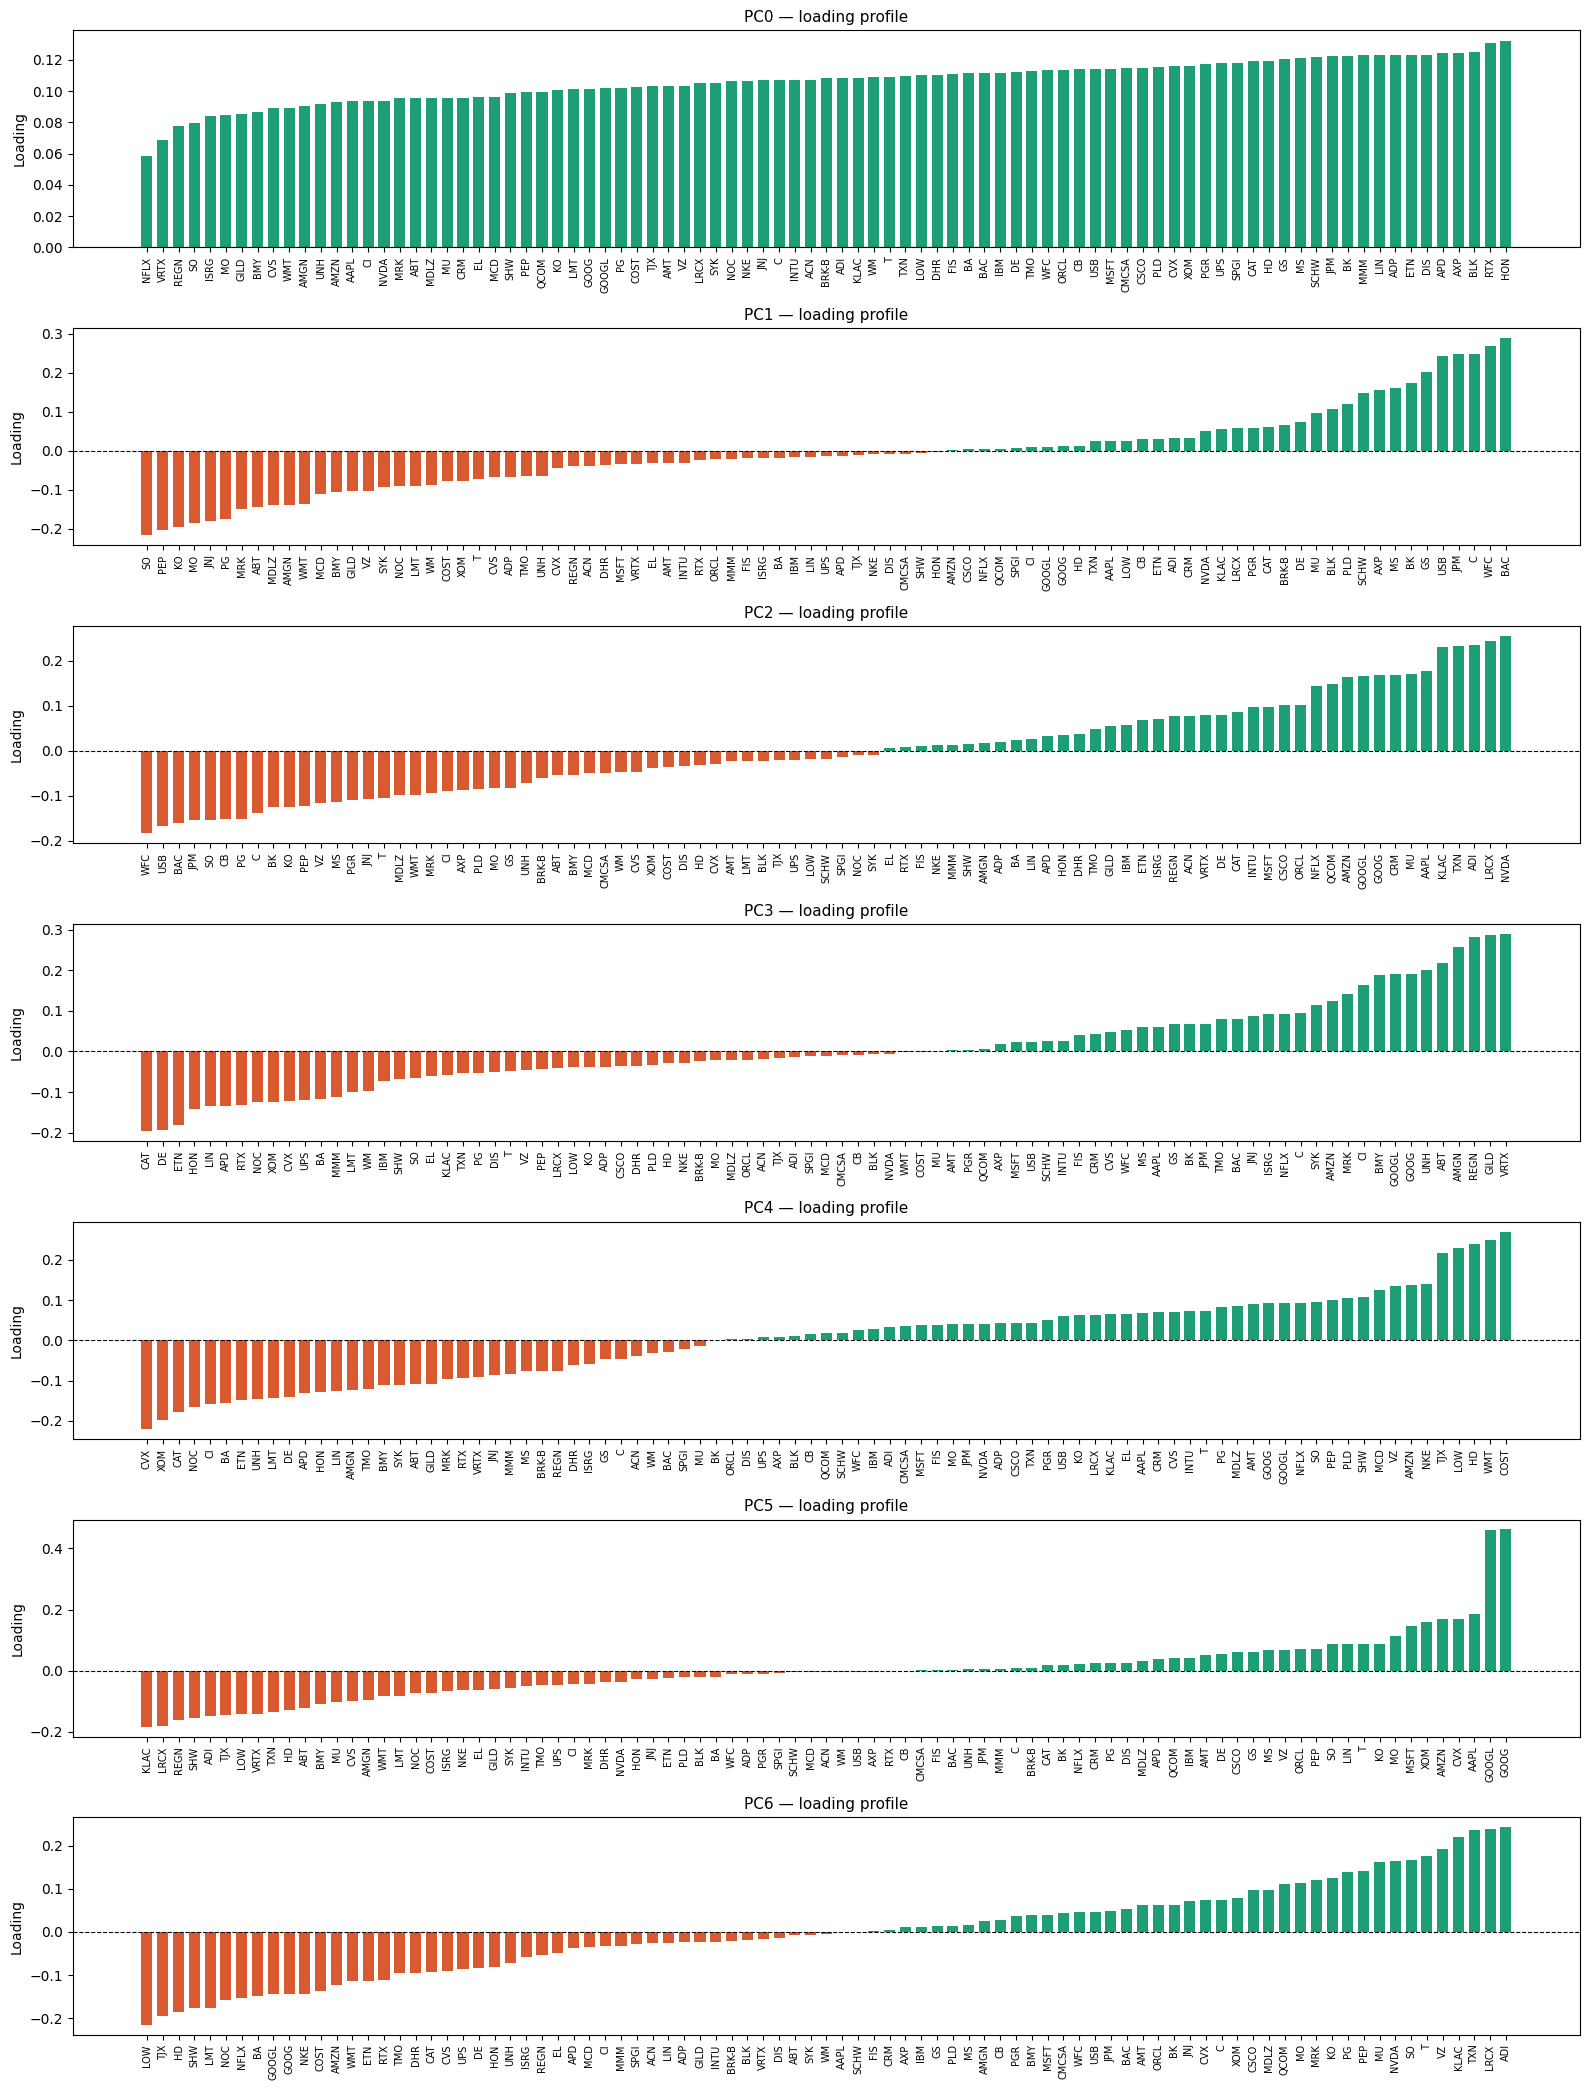

In [38]:
from matplotlib import pyplot as plt


fig, axes = plt.subplots(n_signal, 1, figsize=(16, 3 * n_signal))

for i, pc in enumerate(loadings.index):
    row    = loadings.loc[pc].sort_values()
    colors = ['#D85A30' if v < 0 else '#1D9E75' for v in row.values]
    
    axes[i].bar(row.index, row.values, color=colors, width=0.7)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{pc} — loading profile', fontsize=11)
    axes[i].set_xticks(range(len(row)))
    axes[i].set_xticklabels(row.index, rotation=90, fontsize=7)
    axes[i].set_ylabel('Loading')

plt.tight_layout()
plt.show()

#### PCs Growth 

In [39]:
# Rolling window parameters
window  = 252        # 1 trading year
step    = 21         # roll forward 1 month at a time

dates        = []
pc0_shares   = []
n_signals    = []
enbs         = []

for start in range(0, T - window, step):
    end     = start + window
    window_returns = returns_scaled[start:end, :]

    # PCA on this window
    pca_roll = PCA()
    pca_roll.fit(window_returns)

    ev_roll  = pca_roll.explained_variance_
    evec_roll = pca_roll.components_

    # Marchenko-Pastur for this window
    T_w, N_w      = window_returns.shape
    lam_noise     = (1 + np.sqrt(N_w / T_w))**2
    sig_mask      = ev_roll > lam_noise
    n_sig         = sig_mask.sum()

    sig_ev        = ev_roll[sig_mask]
    sig_evec      = evec_roll[sig_mask]

    # PC0 share of total explained variance
    pc0_share     = sig_ev[0] / sig_ev.sum()

    # ENB of equal-weighted portfolio in this window
    betas_roll    = sig_evec @ weights
    rc_roll       = (betas_roll**2) * sig_ev
    p_roll        = rc_roll / rc_roll.sum()
    enb_roll      = np.exp(-np.sum(p_roll * np.log(p_roll + 1e-10)))

    # Record date at end of window
    dates.append(returns.index[end - 1])
    pc0_shares.append(pc0_share)
    n_signals.append(n_sig)
    enbs.append(enb_roll)

# Build results DataFrame
roll_df = pd.DataFrame({
    'PC0_share' : pc0_shares,
    'N_signal'  : n_signals,
    'ENB'       : enbs
}, index=dates)

print(roll_df.describe().round(4))

       PC0_share  N_signal       ENB
count   168.0000  168.0000  168.0000
mean      0.8629    3.3690    1.0084
std       0.1202    4.3051    0.0143
min       0.5977    1.0000    1.0000
25%       0.7659    1.0000    1.0000
50%       0.8570    2.0000    1.0020
75%       1.0000    3.0000    1.0105
max       1.0000   20.0000    1.0842


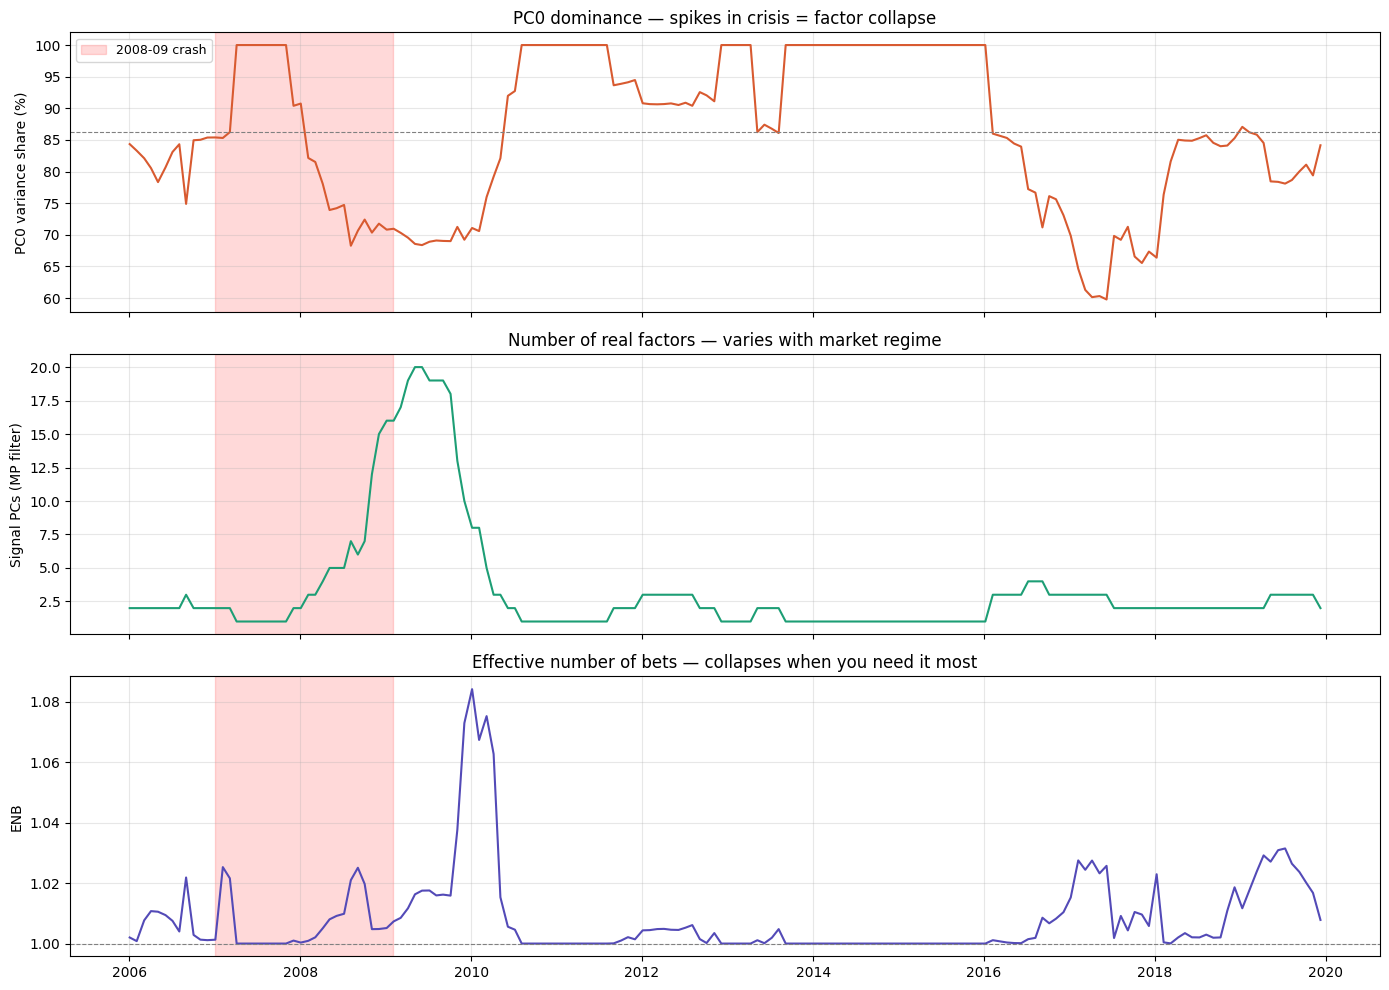

In [40]:
# Plot all three rolling metrics
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — PC0 dominance over time
axes[0].plot(roll_df.index, roll_df['PC0_share'] * 100,
             color='#D85A30', linewidth=1.5)
axes[0].axhline(roll_df['PC0_share'].mean() * 100,
                linestyle='--', color='gray', linewidth=0.8)
axes[0].set_ylabel('PC0 variance share (%)')
axes[0].set_title('PC0 dominance — spikes in crisis = factor collapse')
axes[0].grid(True, alpha=0.3)

# Mark crisis periods
for ax in axes:
    ax.axvspan(pd.Timestamp('2007-01-01'),
               pd.Timestamp('2009-01-30'),
               alpha=0.15, color='red', label='2008-09 crash')


# Panel 2 — number of signal PCs over time
axes[1].plot(roll_df.index, roll_df['N_signal'],
             color='#1D9E75', linewidth=1.5)
axes[1].set_ylabel('Signal PCs (MP filter)')
axes[1].set_title('Number of real factors — varies with market regime')
axes[1].grid(True, alpha=0.3)

# Panel 3 — rolling ENB
axes[2].plot(roll_df.index, roll_df['ENB'],
             color='#534AB7', linewidth=1.5)
axes[2].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[2].set_ylabel('ENB')
axes[2].set_title('Effective number of bets — collapses when you need it most')
axes[2].grid(True, alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## PC Risk Parity Portfolio

In [41]:
from scipy.optimize import minimize

# signal eigenvectors and eigenvalues from your full-sample PCA
V = signal_eigenvectors.values   # shape: (7, 97)
L = signal_eigenvalues.values    # shape: (7,)

def risk_contributions(w):
    betas = V @ w
    rc    = (betas**2) * L
    return rc / rc.sum()

def objective(w):
    rc     = risk_contributions(w)
    target = np.ones(n_signal) / n_signal
    return np.sum((rc - target)**2)

# cap each asset at 10% maximum weight
cap = 0.1

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = [(0.001, cap)] * N
w0          = np.ones(N) / N

result = minimize(
    objective, w0,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = constraints,
    options     = {'maxiter': 1000, 'ftol': 1e-12}
)

w_pcrp = result.x

print(f"Optimization success : {result.success}")
print(f"Max weight           : {w_pcrp.max():.4f}  ({tickers[w_pcrp.argmax()]})")
print(f"Non-zero weights     : {(w_pcrp > 0.001).sum()}")
# Compute ENB for PCRP
betas_pcrp = signal_eigenvectors.values @ w_pcrp
rc_pcrp = (betas_pcrp**2) * signal_eigenvalues.values
var_shares = rc_pcrp / rc_pcrp.sum()
p_pcrp = var_shares
enb_pcrp = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

print(f"ENB                  : {enb_pcrp:.4f}")

Optimization success : True
Max weight           : 0.1000  (VRTX)
Non-zero weights     : 45
ENB                  : 2.4829


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:492: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


In [42]:
pcrp_returns = returns_F.values @ w_pcrp
pcrp_returns = pd.Series(pcrp_returns, index=returns_F.index)
pcrp_returns.describe()

count    1593.000000
mean        0.000322
std         0.011395
min        -0.090740
25%        -0.005269
50%         0.000481
75%         0.005938
max         0.073851
dtype: float64

In [43]:
pcrp_cumulative = (1 + pcrp_returns).cumprod()
pcrp_cumulative

Date
2019-12-31    1.002335
2020-01-02    1.002956
2020-01-03    0.994333
2020-01-06    1.001817
2020-01-07    0.998582
                ...   
2026-04-28    1.522448
2026-04-29    1.506344
2026-04-30    1.525700
2026-05-01    1.508811
2026-05-04    1.506367
Length: 1593, dtype: float64

In [44]:
pcrp_ann_return = pcrp_returns.mean() * 252
pcrp_ann_vol    = pcrp_returns.std()  * np.sqrt(252)
pcrp_sharpe = pcrp_ann_return / pcrp_ann_vol

print(f"Annualized Return : {pcrp_ann_return:.4f}")
print(f"Annualized Vol    : {pcrp_ann_vol:.4f}")
print(f"Sharpe Ratio : {pcrp_sharpe:.4f}")

Annualized Return : 0.0812
Annualized Vol    : 0.1809
Sharpe Ratio : 0.4488


In [45]:
pcrp_peak     = pcrp_cumulative.cummax()
pcrp_drawdown = (pcrp_cumulative - pcrp_peak) / pcrp_peak
pcrp_mdd      = pcrp_drawdown.min()

print(f"Max Drawdown : {pcrp_mdd:.2f}")

Max Drawdown : -0.22


## Risk Contribution pcrp

In [46]:
betas_pcrp  = signal_eigenvectors.values @ w_pcrp
rc_pcrp     = (betas_pcrp**2) * signal_eigenvalues.values
var_shares  = rc_pcrp / rc_pcrp.sum()
p_pcrp      = var_shares
enb_pcrp    = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

risk_df = pd.DataFrame({
    'Variance_Share' : var_shares,
    'Risk_Contrib'   : rc_pcrp
}, index=[
    f'PC{i} — {pc_labels.get(f"PC{i}", f"PC{i}")}'
    for i in range(n_signal)
])

print(risk_df.round(4))
print(f"\nENB PCRP             : {enb_pcrp:.4f}")
betas_ew     = signal_eigenvectors.values @ weights
rc_ew        = (betas_ew**2) * signal_eigenvalues.values
var_shares_ew = rc_ew / rc_ew.sum()
enb_ew       = np.exp(-np.sum(var_shares_ew * np.log(var_shares_ew + 1e-10)))

print(f"ENB Equal-Weighted   : {enb_ew:.4f}")
print(f"Diversification Ratio: {enb_pcrp/N*100:.2f}%")

                                      Variance_Share  Risk_Contrib
PC0 — Market Beta                             0.7220        0.3052
PC1 — Defensives vs Financials                0.0683        0.0288
PC2 — Banking vs Tech Growth                  0.0017        0.0007
PC3 — Biotech vs Semiconductors               0.1552        0.0656
PC4 — Semiconductor vs Mega Cap Tech          0.0338        0.0143
PC5 — Defense vs Tobacco and Telecom          0.0188        0.0080
PC6 — PC6                                     0.0002        0.0001

ENB PCRP             : 2.4829
ENB Equal-Weighted   : 1.0053
Diversification Ratio: 2.85%


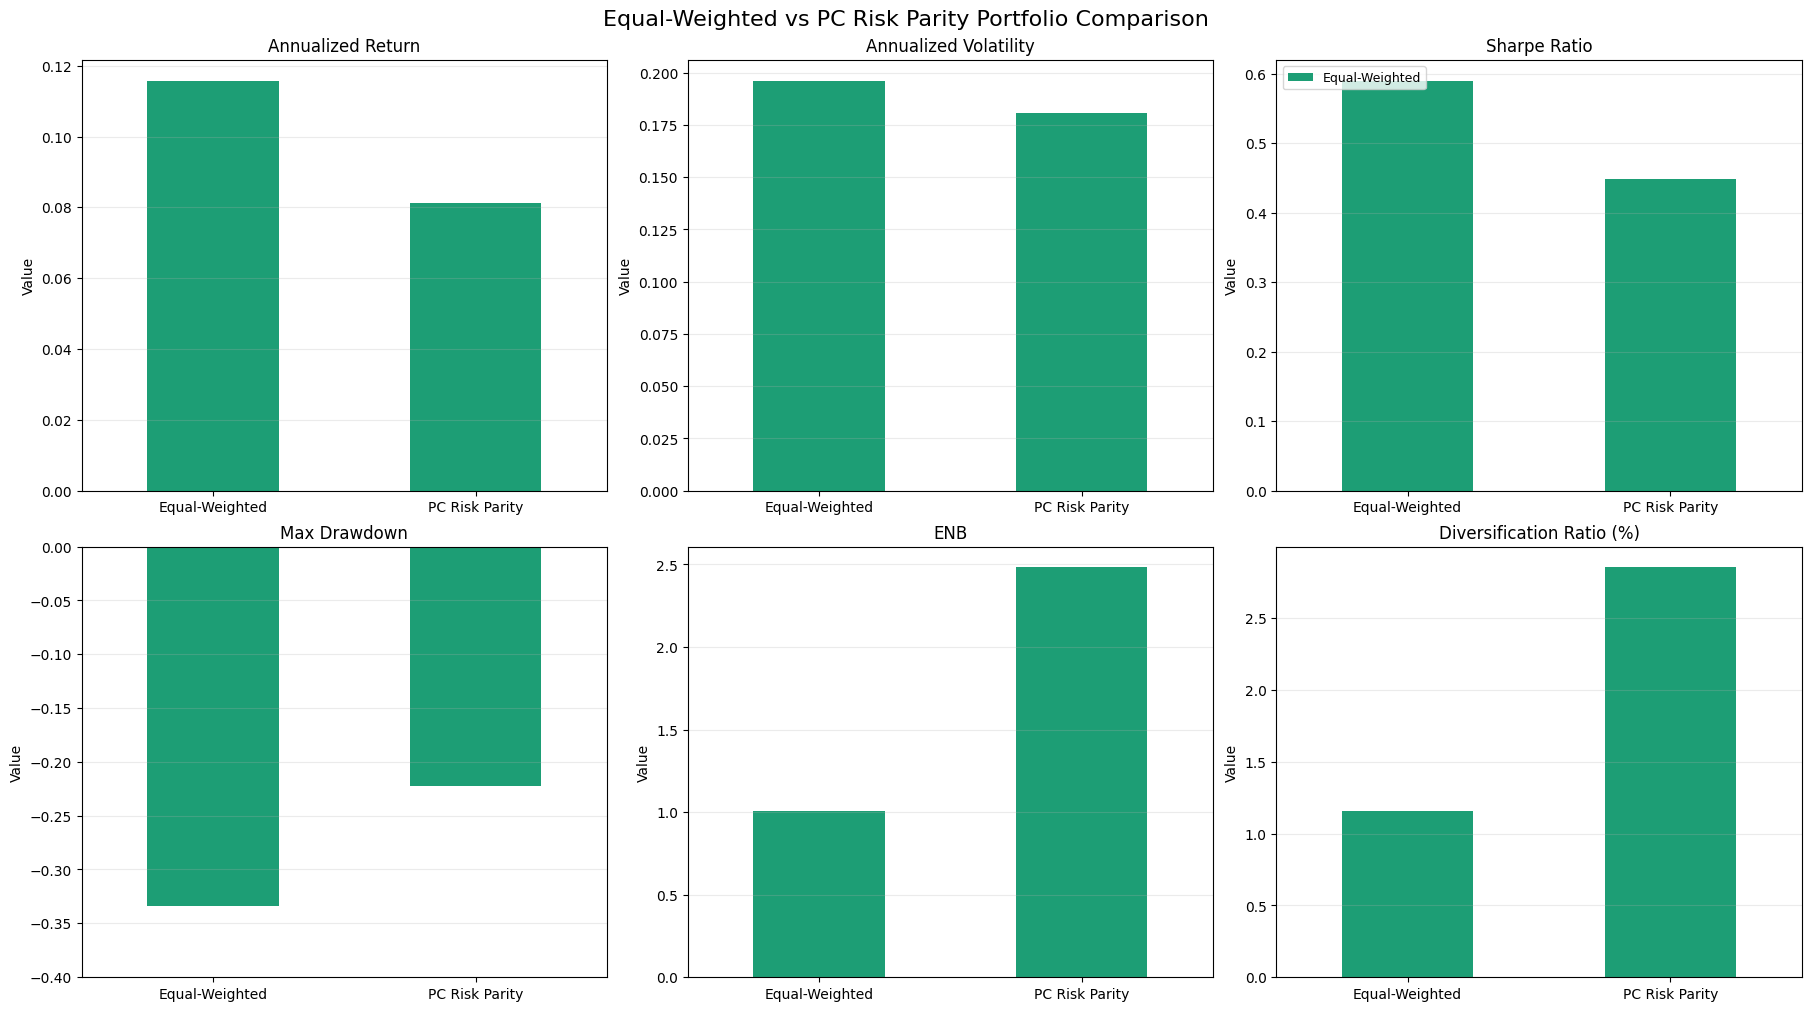

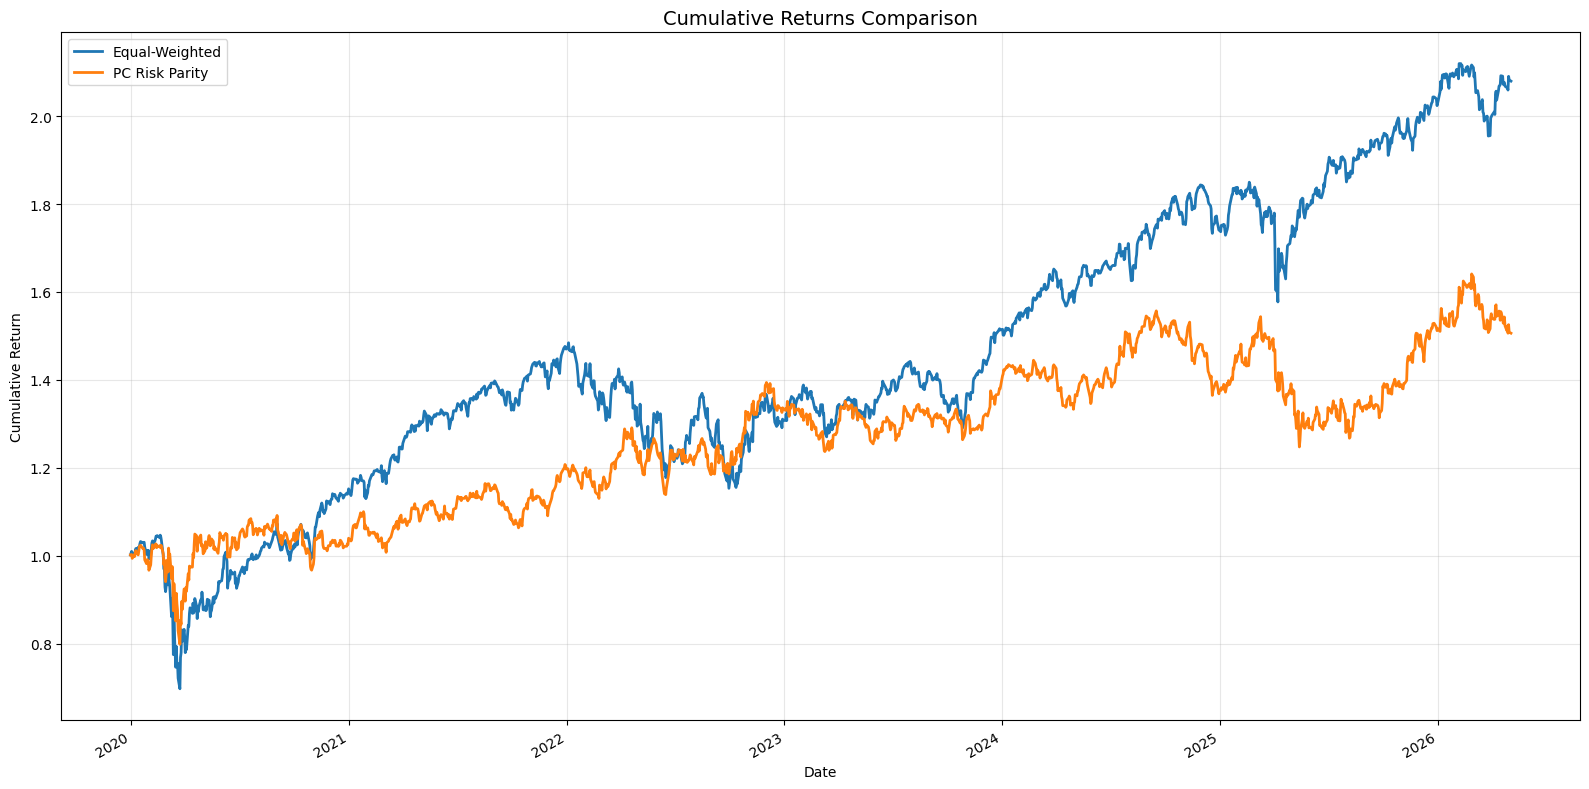

In [47]:
comparison = pd.DataFrame({
    'Equal-Weighted': [
        ew_ann_return,
        ew_ann_vol,
        ew_sharpe,
        ew_drawdown.min(),
        enb_ew,
        enb_ew / N * 100
    ],
    'PC Risk Parity': [
        pcrp_ann_return,
        pcrp_ann_vol,
        pcrp_sharpe,
        pcrp_mdd,
        enb_pcrp,
        enb_pcrp / N * 100
    ]
}, index=[
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'ENB',
    'Diversification Ratio (%)'
])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for ax, metric in zip(axes.flatten(), comparison.index):
    comparison.loc[[metric]].T.plot(
        kind='bar',
        ax=ax,
        color=['#1D9E75', '#D85A30'],
        legend=False,
        rot=0
    )
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.25)
    if metric == 'Max Drawdown':
        ax.set_ylim(comparison.loc['Max Drawdown'].min() * 1.2, 0)

for ax in axes[-1, :]:
    ax.set_xlabel('')

axes[0, 2].legend(comparison.columns, loc='upper left', fontsize=9)

plt.suptitle('Equal-Weighted vs PC Risk Parity Portfolio Comparison', fontsize=16)
plt.show()

# Add cumulative returns comparison
cum_returns_comparison = pd.DataFrame({
    'Equal-Weighted': cum_returns,
    'PC Risk Parity': pcrp_cumulative
})

fig, ax = plt.subplots(figsize=(16, 8))
cum_returns_comparison.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Returns Comparison', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# save final weights
np.save('w_pcrp_final.npy', w_pcrp)
np.save('w_ew_final.npy',   weights)
print("Weights saved.")

Weights saved.


## Crisis stress test 

In [49]:
crises = {
    'COVID Crash'    : ('2020-02-01', '2020-04-30'),
    'Rate Shock 2022': ('2022-01-01', '2022-12-31')
}

results = []

for crisis_name, (start, end) in crises.items():

    # --- Portfolio returns (from test set) ---
    ew_crisis   = portfolio_returns[start:end]
    pcrp_crisis = pcrp_returns[start:end]

    if len(ew_crisis) == 0:
        print(f"WARNING: No data for {crisis_name}")
        continue

    # --- Cumulative wealth ---
    ew_cum   = (1 + ew_crisis).cumprod()
    pcrp_cum = (1 + pcrp_crisis).cumprod()

    # --- Total return ---
    ew_total   = ew_cum.iloc[-1] - 1
    pcrp_total = pcrp_cum.iloc[-1] - 1

    # --- Sharpe (rf = 0 for now) ---
    ew_sharpe_c   = (ew_crisis.mean() / ew_crisis.std()) * np.sqrt(252)
    pcrp_sharpe_c = (pcrp_crisis.mean() / pcrp_crisis.std()) * np.sqrt(252)

    # --- Maximum Drawdown ---
    ew_mdd_c   = ((ew_cum - ew_cum.cummax()) / ew_cum.cummax()).min()
    pcrp_mdd_c = ((pcrp_cum - pcrp_cum.cummax()) / pcrp_cum.cummax()).min()

    # --- ENB during crisis window ---
    # slice from test returns DataFrame using DatetimeIndex
    crisis_window = returns_F.loc[start:end]

    # scale using TRAINING scaler only — no refitting
    crisis_scaled = scaler.transform(crisis_window)

    # fit PCA on crisis window
    pca_c = PCA()
    pca_c.fit(crisis_scaled)

    ev_c  = pca_c.explained_variance_
    evc_c = pca_c.components_

    # Marchenko-Pastur threshold for this window
    T_c, N_c = crisis_scaled.shape
    lam_c    = (1 + np.sqrt(N_c / T_c))**2
    sig_c    = ev_c > lam_c
    ev_sig   = ev_c[sig_c]
    evc_sig  = evc_c[sig_c]

    # ENB equal-weighted
    b_ew     = evc_sig @ weights
    rc_ew    = (b_ew**2) * ev_sig
    p_ew     = rc_ew / rc_ew.sum()
    enb_ew_c = np.exp(-np.sum(p_ew * np.log(p_ew + 1e-10)))

    # ENB PCRP
    b_pc     = evc_sig @ w_pcrp
    rc_pc    = (b_pc**2) * ev_sig
    p_pc     = rc_pc / rc_pc.sum()
    enb_pc_c = np.exp(-np.sum(p_pc * np.log(p_pc + 1e-10)))

    results.append({
        'Crisis'            : crisis_name,
        'EW Total Return'   : ew_total,
        'PCRP Total Return' : pcrp_total,
        'EW MDD'            : ew_mdd_c,
        'PCRP MDD'          : pcrp_mdd_c,
        'EW Sharpe'         : ew_sharpe_c,
        'PCRP Sharpe'       : pcrp_sharpe_c,
        'EW ENB'            : enb_ew_c,
        'PCRP ENB'          : enb_pc_c,
        'Signal PCs'        : sig_c.sum()
    })

crisis_df = pd.DataFrame(results).set_index('Crisis')
print(crisis_df.round(4).T)

Crisis             COVID Crash  Rate Shock 2022
EW Total Return        -0.1342          -0.1319
PCRP Total Return       0.0598           0.1155
EW MDD                 -0.3559          -0.2363
PCRP MDD               -0.2221          -0.1177
EW Sharpe              -0.6032          -0.5364
PCRP Sharpe             0.7078           0.7183
EW ENB                  1.0103           1.0605
PCRP ENB                1.6121           2.3984
Signal PCs             12.0000           6.0000


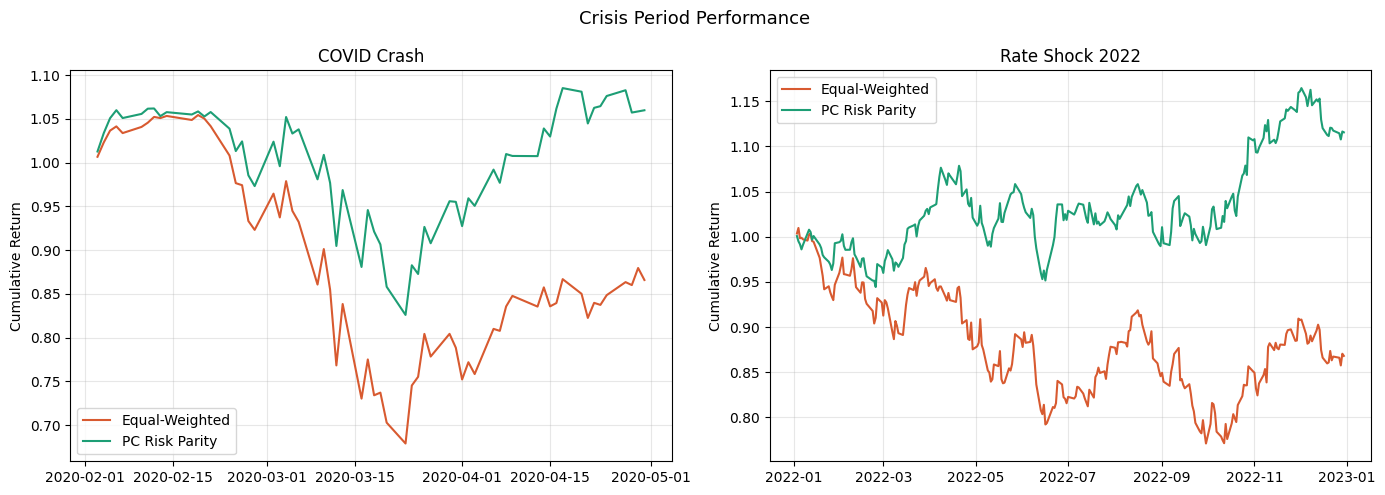

In [50]:
# plot crisis cumulative returns side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (crisis_name, (start, end)) in enumerate(crises.items()):
    ew_c   = (1 + portfolio_returns[start:end]).cumprod()
    pcrp_c = (1 + pcrp_returns[start:end]).cumprod()
    
    axes[i].plot(ew_c,   label='Equal-Weighted', color='#D85A30', linewidth=1.5)
    axes[i].plot(pcrp_c, label='PC Risk Parity', color='#1D9E75', linewidth=1.5)
    axes[i].set_title(crisis_name)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylabel('Cumulative Return')

plt.suptitle('Crisis Period Performance', fontsize=13)
plt.tight_layout()
plt.show()